# FRA 3x6 Hedging with SOFR Futures

This project simulates the hedging of a short Forward Rate Agreement (FRA) position using SOFR Futures contracts.

A client locks a 3x6 FRA at a fixed rate of 2.5% to hedge a $10M floating-rate loan starting in 3 months. As the market maker, the trader takes the short side of the FRA, receiving the fixed rate and paying the floating SOFR rate.

The 3x6 forward rate is derived from the SOFR spot curve and evolves according to a Geometric Brownian Motion over a 21-day simulation horizon. The hedge is constructed using SOFR Futures contracts, with the number of contracts determined by the DV01 of the FRA.

The entire simulation is implemented in Python using NumPy, Pandas and Matplotlib.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Model Assumptions

## Market Data

* SOFR 3-month spot rate: 2.3%
* SOFR 6-month spot rate: 2.4%
* 3x6 Forward rate F0: derived from SOFR curve (no-arbitrage)
* Forward rate volatility: 1% (annualized)
* Risk-free discount rate: 2% (continuous)

## FRA Parameters

* Strike rate K: 2.5%
* Notional: $10,000,000
* FRA start: T = 0.25 (3 months from today)
* FRA tenor: delta = 0.25 (3-month period, 3x6)
* Position: Short FRA — receive fixed K, pay floating SOFR

## Hedge Instrument

* SOFR Futures contracts (CME)
* DV01 per contract: 25 dollars (fixed)
* Notional per contract: 1,000,000 dollars
* Hedge ratio rebalanced daily based on FRA DV01

## Simulation Setup

* 21 trading days (1 month)
* Daily time step: dt = 1/252
* Forward rate follows Geometric Brownian Motion
* Hedge ratio rounded to nearest whole contract

In [5]:
# Market Data
# SOFR spot rates observed today on the yield curve
SOFR_3m = 0.023  # 3-month SOFR spot rate
SOFR_6m = 0.024  # 6-month SOFR spot rate

# FRA Parameters
K       = 0.025       # fixed strike rate agreed with client
N       = 10_000_000  # notional ($10M)
T_start = 0.25        # FRA start date (3 months from today, in years)
delta   = 0.25        # FRA tenor (3 months = 0.25 year)

# Derive the 3x6 forward rate from the SOFR spot curve (no-arbitrage)
# Investing 6 months = investing 3 months, then rolling at the forward rate
F0 = (1/delta) * ((1 + SOFR_6m * 2 * delta) / (1 + SOFR_3m * delta) - 1)
print(f"Implied 3x6 Forward Rate (F0): {F0*100:.4f}%")

sigma = 0.01  # annualized forward rate volatility
r     = 0.02  # risk-free discount rate (continuous compounding)

# Simulation
dt     = 1/252  # daily time step (trading days)
n_days = 21     # 1 month of hedging simulation

Implied 3x6 Forward Rate (F0): 2.4857%


# Forward Rate Simulation

The 3x6 forward rate evolves under Geometric Brownian Motion

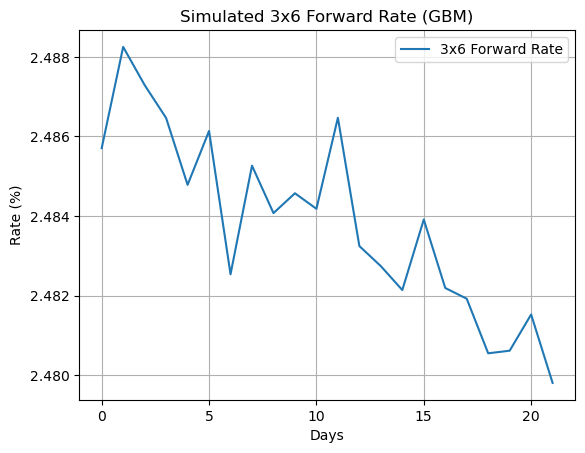

In [13]:
# Simulate the 3x6 forward rate over 21 days using Geometric Brownian Motion
def simulate_forward(F0, sigma, n_days, dt):
    np.random.seed(1)
    Forward = ((-sigma**2/2*dt) + sigma*np.sqrt(dt) * np.random.randn(n_days))
    F = F0 * np.exp(np.cumsum(Forward))
    F = np.insert(F, 0, F0)  # insert F0 at day 0
    return F

forward = simulate_forward(F0, sigma, n_days, dt)

# Time remaining until FRA start, floored at 0
time_to_start = np.maximum(T_start - np.arange(n_days + 1) * dt, 0)

plt.plot(range(n_days+1), forward*100, label='3x6 Forward Rate')
plt.title('Simulated 3x6 Forward Rate (GBM)')
plt.xlabel('Days')
plt.ylabel('Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

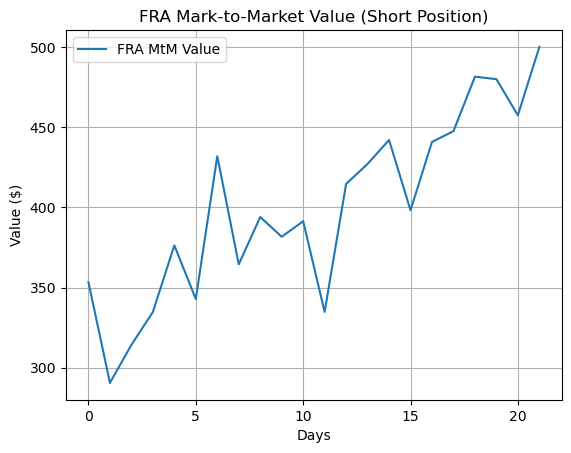

In [15]:
# Mark-to-Market value of the FRA (short position)
def fra_value(F, K, r, delta, time_to_start):
    # (K−F): receive fixed K, pay floating F
    fra = N * delta * ((K - F) / (1 + delta*F)) * np.exp(-r*time_to_start)
    return fra

fra = fra_value(forward, K, r, delta, time_to_start)

plt.plot(range(n_days+1), fra, label='FRA MtM Value')
plt.title('FRA Mark-to-Market Value (Short Position)')
plt.xlabel('Days')
plt.ylabel('Value ($)')
plt.grid(True)
plt.legend()
plt.show()

# DV01 and Hedge Construction

## DV01 of the FRA

The DV01 measures the sensitivity of the FRA value to a 1 basis point (0.01%) move in the forward rate:

The negative sign confirms that a short FRA loses value when rates rise.

## Hedge Ratio

Each SOFR Futures contract has a fixed DV01 of 25 dollars (CME standard: $1M notional x 0.25 x 1bp).
A **short** futures position offsets the short FRA exposure: when rates rise, the short future gains, compensating the FRA loss.

In [8]:
# DV01: sensitivity of FRA value to a 1bp move in the forward rate
# dV/dF = -N*delta / (1+delta*F)^2 * exp(-r*(T-t))
def fra_dv01(F, N, delta, r, time_to_start):
    return ((-N * delta) / (1+delta*F)**2 * np.exp(-r*time_to_start)) * 0.0001

fra_DV01 = fra_dv01(forward, N, delta, r, time_to_start)

# Number of SOFR Futures contracts to short
# Hedge ratio = -DV01_FRA / DV01_future
futures_dv01 = -25  # DV01 per contract: short position = negative
hedge = -fra_DV01 / futures_dv01
hedge = np.round(hedge)  # round to nearest whole contract

# Daily P&L and Hedge Effectiveness

## P&L Decomposition

* **FRA P&L**: daily change in MtM value of the short FRA
* **Futures P&L**: daily gain/loss on the short SOFR futures position
* **Net P&L**: sum of both — should remain close to zero if hedge is effective

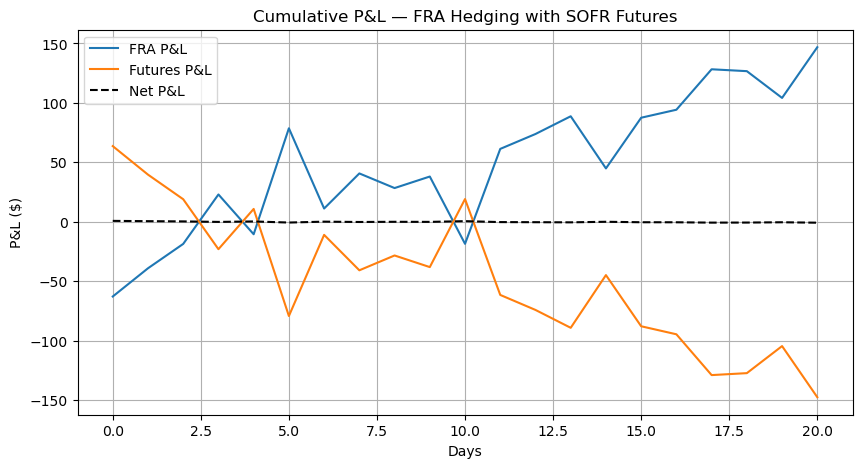

In [16]:
# Daily P&L of the FRA position
fra_pnl = np.diff(fra)

# Daily change in the forward rate
rate_change = np.diff(forward)

# Daily P&L of the futures hedge
# Short futures gain when rates rise (future price falls)
# P&L = contracts x DV01_future x rate_change_in_bps
futures_pnl = hedge[:-1] * futures_dv01 * (rate_change / 0.0001)

# Net P&L
total_pnl = fra_pnl + futures_pnl

# Cumulative P&L
cum_fra_pnl     = np.cumsum(fra_pnl)
cum_futures_pnl = np.cumsum(futures_pnl)
cum_total_pnl   = np.cumsum(total_pnl)

plt.figure(figsize=(10, 5))
plt.plot(range(n_days), cum_fra_pnl,     label='FRA P&L')
plt.plot(range(n_days), cum_futures_pnl, label='Futures P&L')
plt.plot(range(n_days), cum_total_pnl,   label='Net P&L', linestyle='--', color='black')
plt.title('Cumulative P&L — FRA Hedging with SOFR Futures')
plt.xlabel('Days')
plt.ylabel('P&L ($)')
plt.grid(True)
plt.legend()
plt.show()

# Hedge Summary Table

Daily breakdown of the forward rate, FRA MtM value, DV01, hedge ratio and P&L components.

In [17]:
# Build a daily summary DataFrame
df_hedge = pd.DataFrame({
    'Day'               : range(n_days + 1),
    'Forward Rate (%)'  : (forward * 100).round(4),
    'FRA Value ($)'     : fra.round(2),
    'DV01 ($)'          : fra_DV01.round(2),
})

# P&L columns (one row shorter — pad day 0 with NaN)
pnl_cols = pd.DataFrame({
    'FRA P&L ($)'     : np.concatenate([[np.nan], fra_pnl.round(2)]),
    'Futures P&L ($)' : np.concatenate([[np.nan], futures_pnl.round(2)]),
    'Net P&L ($)'     : np.concatenate([[np.nan], total_pnl.round(2)]),
})

df_hedge = pd.concat([df_hedge, pnl_cols], axis=1).set_index('Day')
df_hedge

,Forward Rate (%),FRA Value ($),DV01 ($),FRA P&L ($),Futures P&L ($),Net P&L ($)
Day,,,,,,
0,2.4857,353.34,-245.69,NaN,NaN,NaN
1,2.4883,290.46,-245.71,-62.88,63.61,0.73
2,2.4873,314.21,-245.73,23.74,-23.98,-0.24
3,2.4865,334.70,-245.75,20.50,-20.70,-0.20
4,2.4848,376.29,-245.77,41.59,-42.01,-0.43
5,2.4861,342.82,-245.79,-33.47,33.86,0.39
6,2.4825,431.95,-245.81,89.13,-90.06,-0.93
7,2.4853,364.46,-245.83,-67.49,68.24,0.75
8,2.4841,393.98,-245.85,29.52,-29.80,-0.28


In [18]:
# FRA cash settlement at expiration
# L_realized = last simulated forward rate (proxy for realized SOFR at T_start)
def fra_payoff(F_realized, K, N, delta):
    return N * delta * (K - F_realized) / (1 + delta * F_realized)

L_realized = forward[-1]
payoff = fra_payoff(L_realized, K, N, delta)

print(f"Realized SOFR at expiry : {L_realized*100:.4f}%")
print(f"Strike K                : {K*100:.2f}%")
print(f"FRA Settlement Payoff   : ${payoff:,.2f}")

Realized SOFR at expiry : 2.4798%
Strike K                : 2.50%
FRA Settlement Payoff   : $501.79


# Results

The simulation demonstrates that a short FRA position can be effectively hedged using SOFR Futures contracts.

The DV01-based hedge ratio is rebalanced daily, maintaining near-zero net P&L throughout the 21-day simulation horizon.

Residual profit and loss remain because:
* The hedge ratio is rounded to whole contracts (discrete hedge)
* The FRA DV01 changes slightly as the forward rate evolves (convexity effect)
* Hedging is performed daily rather than continuously

Overall, the net P&L remains below $2 on a $10M notional, confirming the effectiveness of the SOFR Futures hedge.